In [84]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import CouplingMap
from qiskit.synthesis import LieTrotter

from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import (
    generate_time_evolution_circuit,
)
from qiskit_addon_utils.slicing import slice_by_depth, combine_slices
from qiskit_addon_obp.utils.simplify import OperatorBudget
from qiskit_addon_obp import backpropagate
from qiskit_addon_obp.utils.truncating import setup_budget

from rustworkx.visualization import graphviz_draw

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions

from qiskit.transpiler import generate_preset_pass_manager
from samplomatic.transpiler import generate_boxing_pass_manager

from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.post_selection import PostSelector
from qiskit_addon_utils.noise_management.post_selection.transpiler.passes import AddPostSelectionMeasures, AddSpectatorMeasures

from samplomatic import build

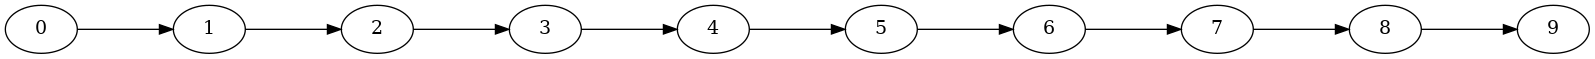

In [85]:
num_qubits = 10
layout = [(i - 1, i) for i in range(1, num_qubits)]

# Instantiate a CouplingMap object
coupling_map = CouplingMap(layout)
graphviz_draw(coupling_map.graph, method="circo")

In [86]:
# Get a qubit operator describing the Heisenberg XYZ model
hamiltonian = generate_xyz_hamiltonian(
    coupling_map,
    coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
    ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
)
print(hamiltonian)

SparsePauliOp(['IIIIIIIXXI', 'IIIIIIIYYI', 'IIIIIIIZZI', 'IIIIIXXIII', 'IIIIIYYIII', 'IIIIIZZIII', 'IIIXXIIIII', 'IIIYYIIIII', 'IIIZZIIIII', 'IXXIIIIIII', 'IYYIIIIIII', 'IZZIIIIIII', 'IIIIIIIIXX', 'IIIIIIIIYY', 'IIIIIIIIZZ', 'IIIIIIXXII', 'IIIIIIYYII', 'IIIIIIZZII', 'IIIIXXIIII', 'IIIIYYIIII', 'IIIIZZIIII', 'IIXXIIIIII', 'IIYYIIIIII', 'IIZZIIIIII', 'XXIIIIIIII', 'YYIIIIIIII', 'ZZIIIIIIII', 'IIIIIIIIIX', 'IIIIIIIIIY', 'IIIIIIIIIZ', 'IIIIIIIIXI', 'IIIIIIIIYI', 'IIIIIIIIZI', 'IIIIIIIXII', 'IIIIIIIYII', 'IIIIIIIZII', 'IIIIIIXIII', 'IIIIIIYIII', 'IIIIIIZIII', 'IIIIIXIIII', 'IIIIIYIIII', 'IIIIIZIIII', 'IIIIXIIIII', 'IIIIYIIIII', 'IIIIZIIIII', 'IIIXIIIIII', 'IIIYIIIIII', 'IIIZIIIIII', 'IIXIIIIIII', 'IIYIIIIIII', 'IIZIIIIIII', 'IXIIIIIIII', 'IYIIIIIIII', 'IZIIIIIIII', 'XIIIIIIIII', 'YIIIIIIIII', 'ZIIIIIIIII'],
              coeffs=[0.39269908+0.j, 0.78539816+0.j, 1.57079633+0.j, 0.39269908+0.j,
 0.78539816+0.j, 1.57079633+0.j, 0.39269908+0.j, 0.78539816+0.j,
 1.57079633+0.j, 0.39269908+0.j, 0.

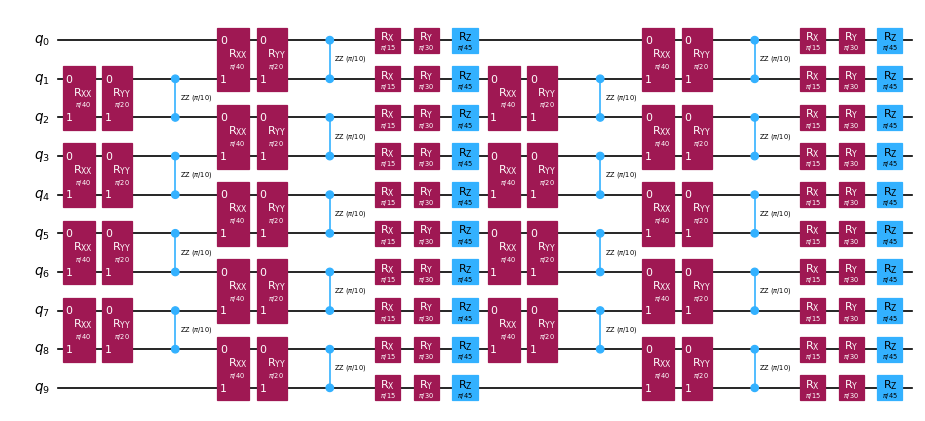

In [87]:
circuit = generate_time_evolution_circuit(
    hamiltonian,
    time=0.2,
    synthesis=LieTrotter(reps=2),
)
circuit.draw("mpl", style="iqp", scale=0.6)

In [88]:
slices = slice_by_depth(circuit, max_slice_depth=1)
print(f"Separated the circuit into {len(slices)} slices.")

Separated the circuit into 18 slices.


In [89]:
op_budget = OperatorBudget(max_qwc_groups=8)
truncation_error_budget = setup_budget(max_error_per_slice=0.005)

In [90]:
observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1 / num_qubits) for i in range(num_qubits)],
    num_qubits=num_qubits,
)
observable

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII'],
              coeffs=[0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j, 0.1+0.j,
 0.1+0.j, 0.1+0.j])

Backpropagated 7 slices.
New observable has 82 terms, which can be combined into 8 groups.
After truncation, the error in our observable is bounded by 3.266e-02
Note that backpropagating one more slice would result in 114 terms across 12 groups.
The remaining circuit after backpropagation looks as follows:


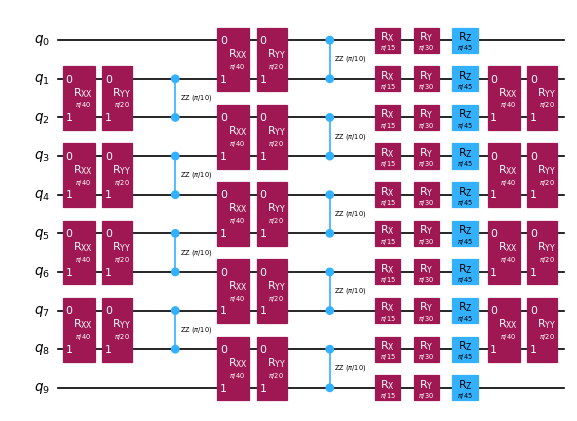

In [91]:
bp_obs_trunc, remaining_slices_trunc, metadata = backpropagate(
    observable,
    slices, 
    operator_budget=op_budget,
    truncation_error_budget=truncation_error_budget,
)
bp_circuit_trunc = combine_slices(
    remaining_slices_trunc, include_barriers=False
)

print(f"Backpropagated {metadata.num_backpropagated_slices} slices.")
print(
    f"New observable has {len(bp_obs_trunc.paulis)} terms, which can be combined into {len(bp_obs_trunc.group_commuting(qubit_wise=True))} groups.\n"
    f"After truncation, the error in our observable is bounded by {metadata.accumulated_error(0):.3e}"
)
print(
    f"Note that backpropagating one more slice would result in {metadata.backpropagation_history[-1].num_paulis[0]} terms "
    f"across {metadata.backpropagation_history[-1].num_qwc_groups} groups."
)
print("The remaining circuit after backpropagation looks as follows:")
bp_circuit_trunc.draw("mpl", scale=0.6)

In [92]:
from qiskit import QuantumCircuit

# Group the truncated observable into qubit-wise commuting groups
commuting_groups = bp_obs_trunc.group_commuting(qubit_wise=True)

measured_circuits = []

for group in commuting_groups:
    meas_qc = bp_circuit_trunc.copy()
    
    for i in range(meas_qc.num_qubits):
        
        has_x = any(pauli.x[i] and not pauli.z[i] for pauli in group.paulis)
        has_y = any(pauli.x[i] and pauli.z[i] for pauli in group.paulis)
        
        if has_x:
            meas_qc.h(i)         # Rotate X to Z
        elif has_y:
            meas_qc.sdg(i)
            meas_qc.h(i)         # Rotate Y to Z
            
    meas_qc.measure_all()
    measured_circuits.append(meas_qc)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
# use your api key
service = QiskitRuntimeService()
backend = service.backend('ibm_marrakesh')
backend_f = service.backend('ibm_marrakesh', use_fractional_gates=True)

qiskit_runtime_service.__init__:WARNING:2026-03-26 09:59:50,171: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-26 09:59:50,172: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-26 09:59:50,521: Using instance: open-instance, plan: open


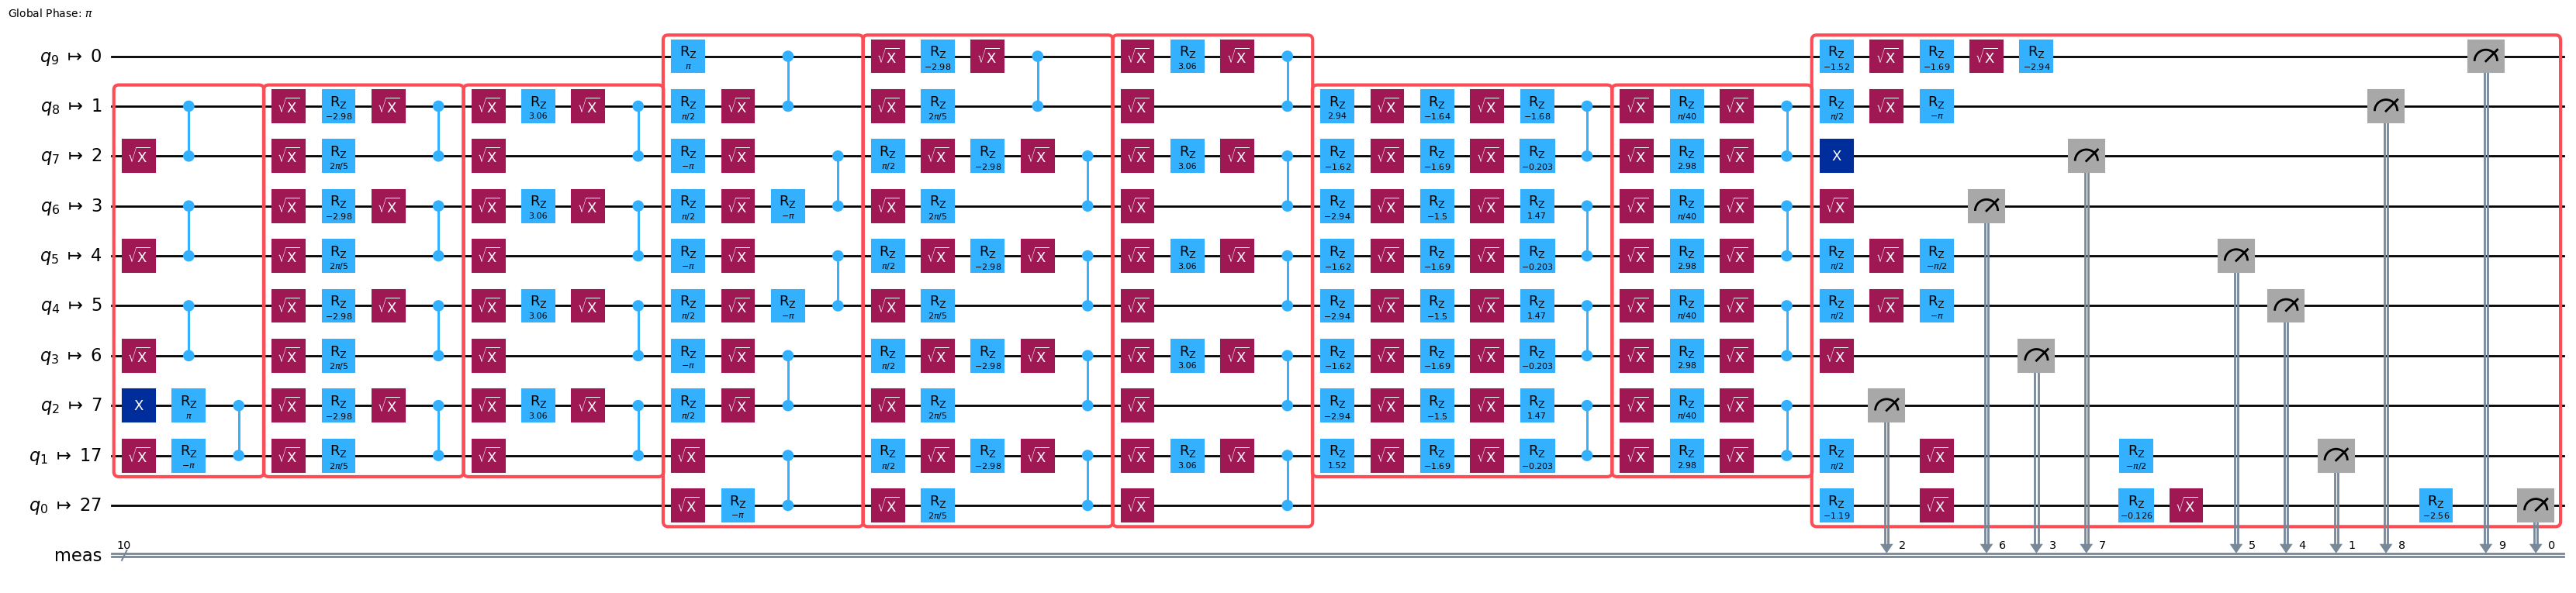

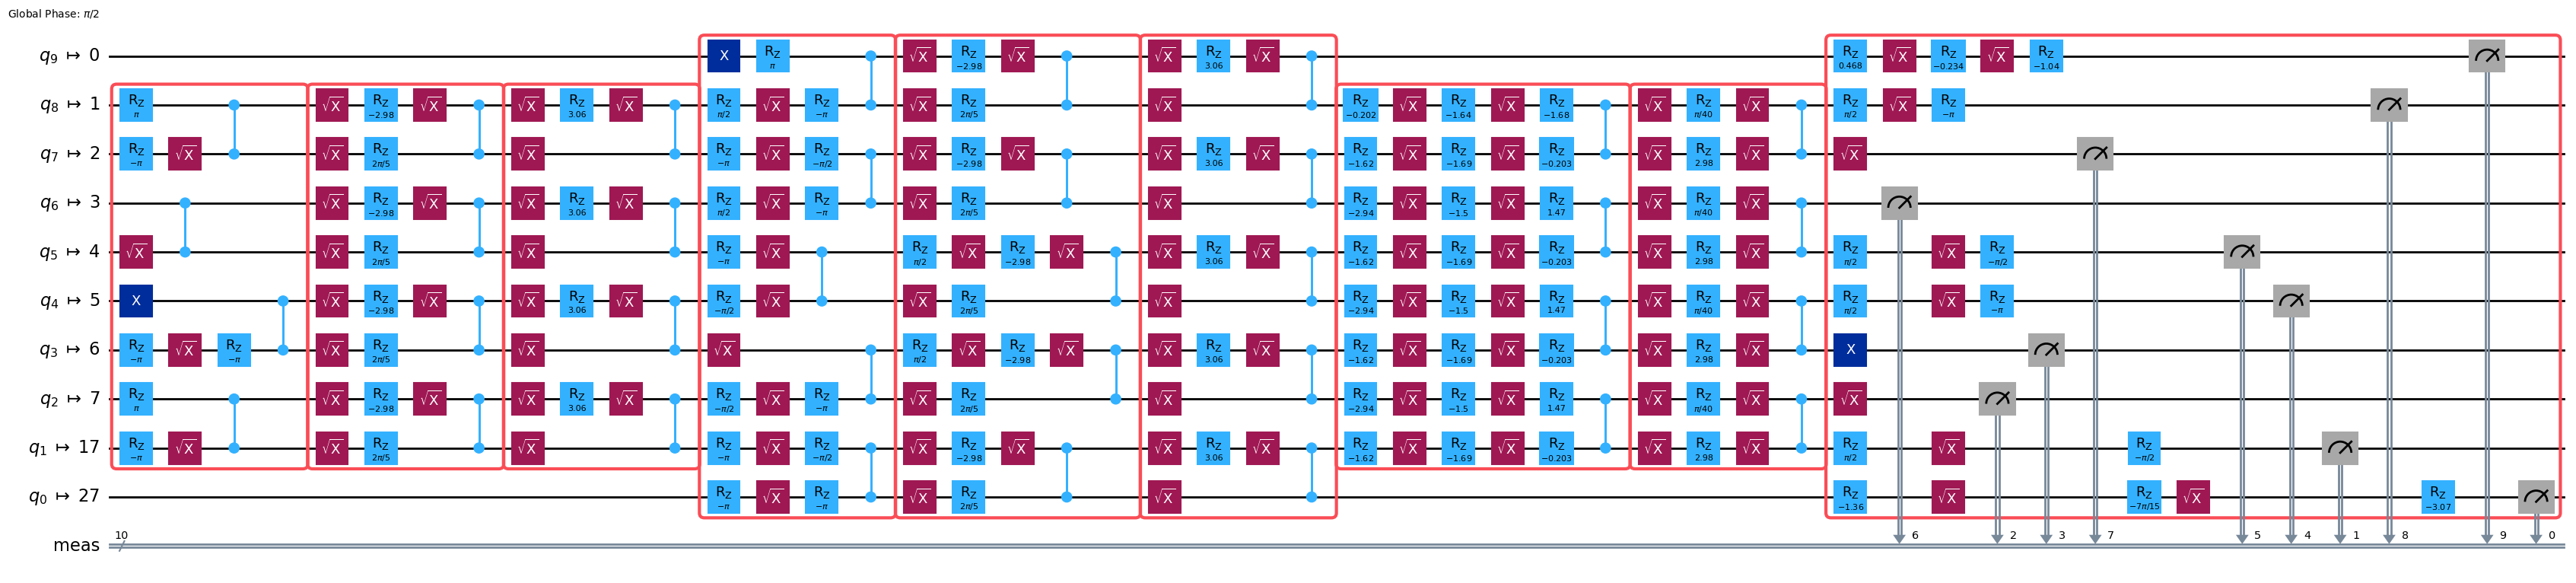

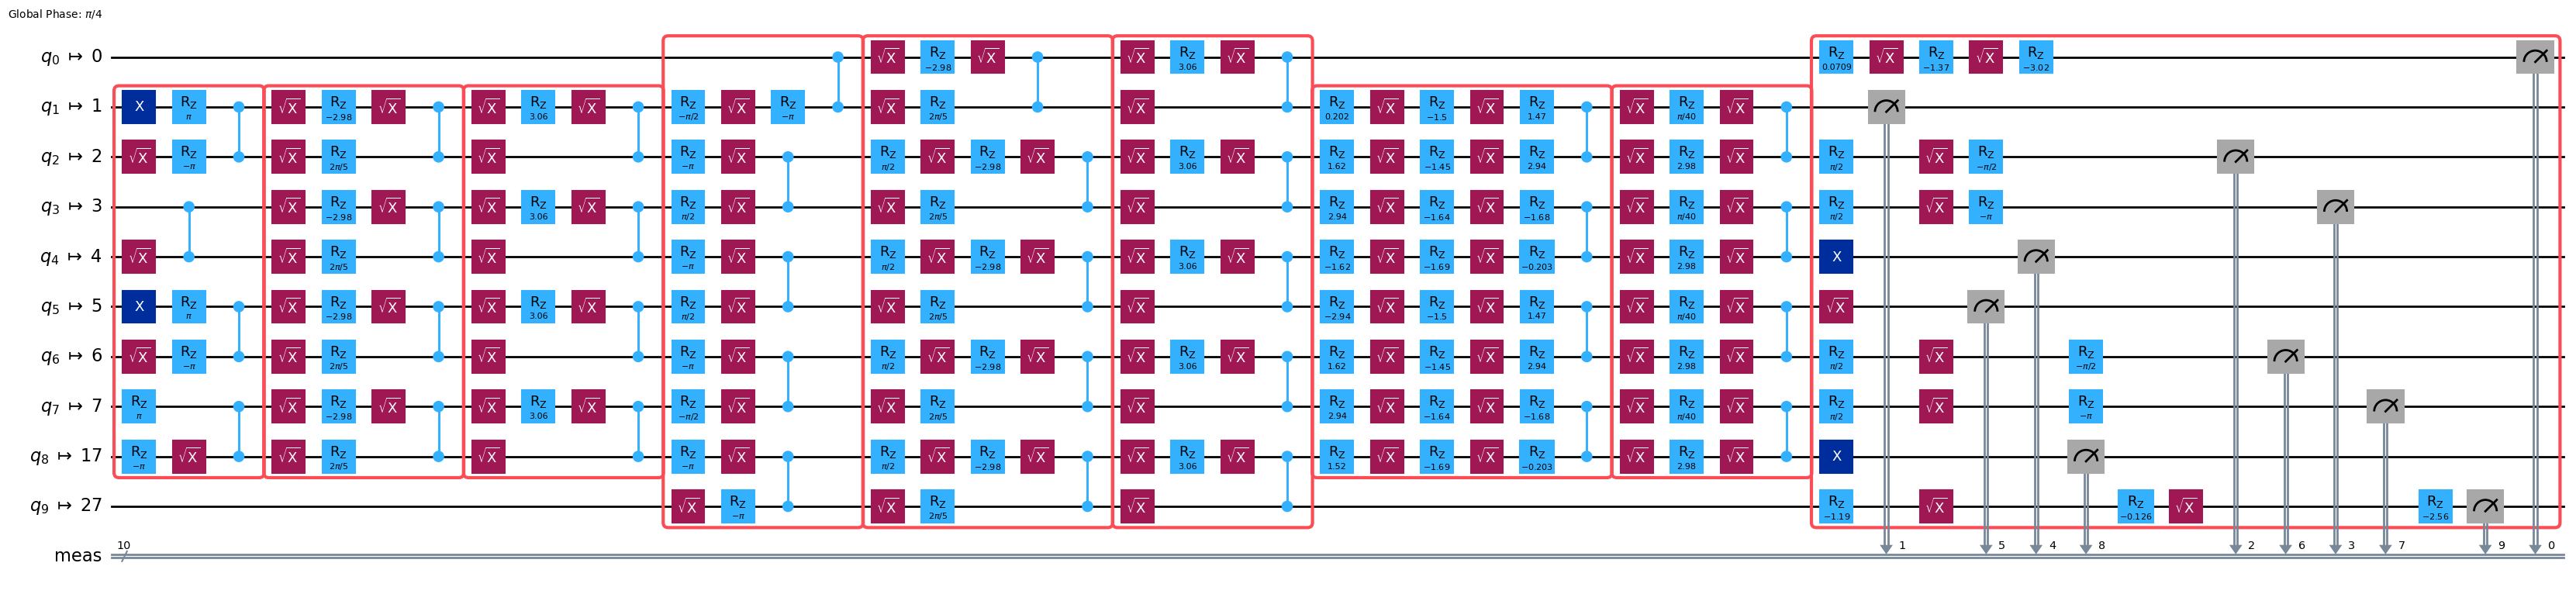

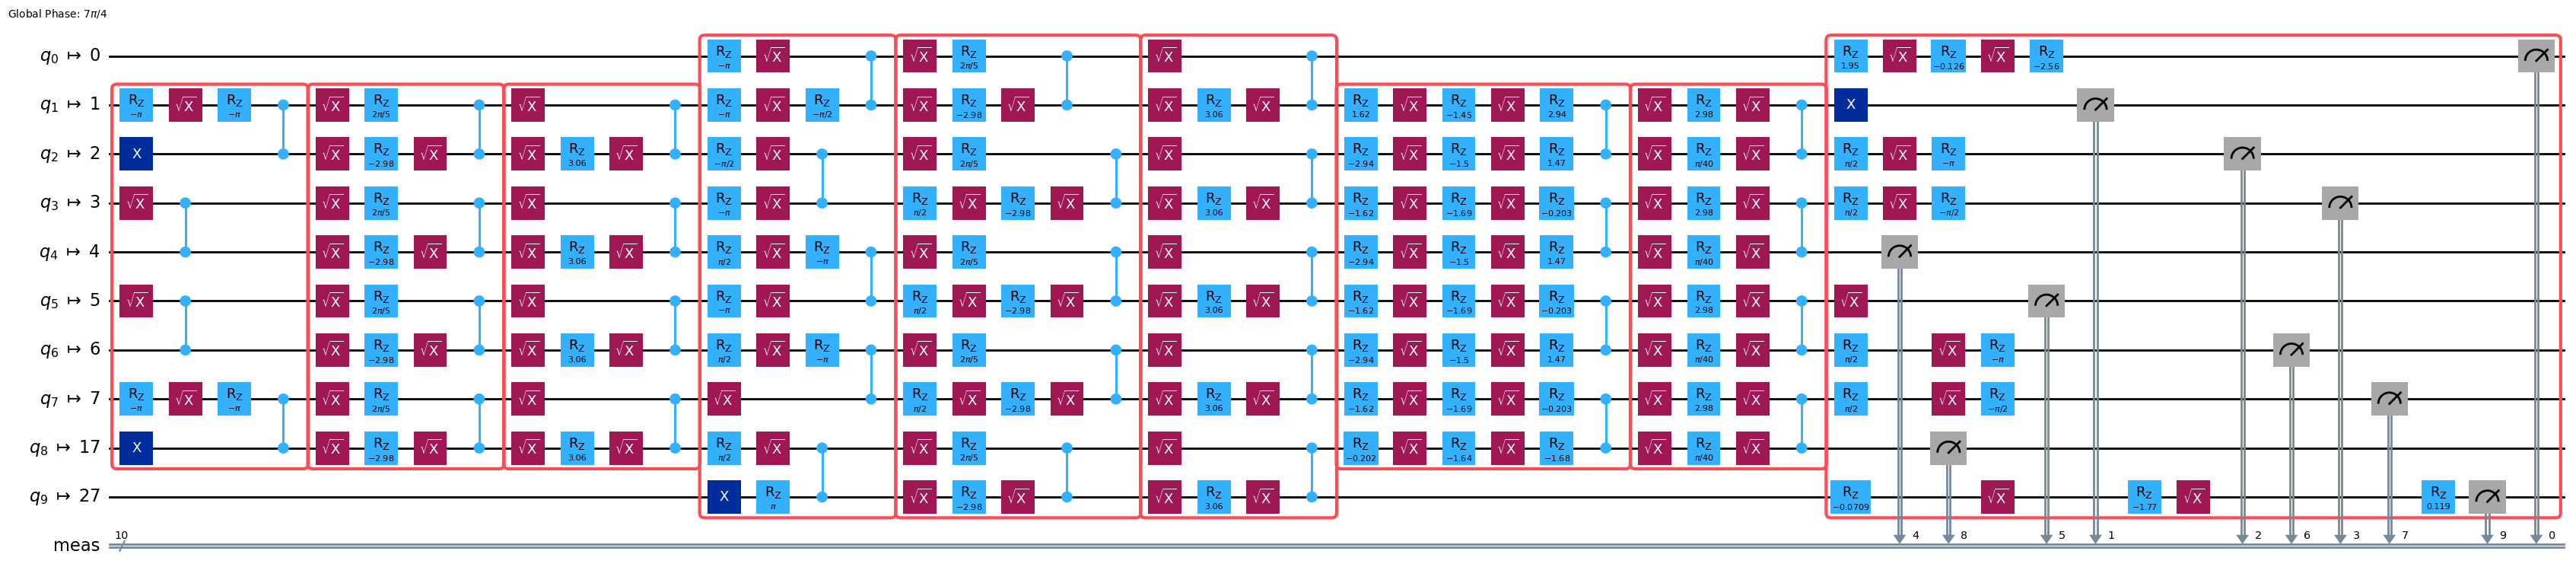

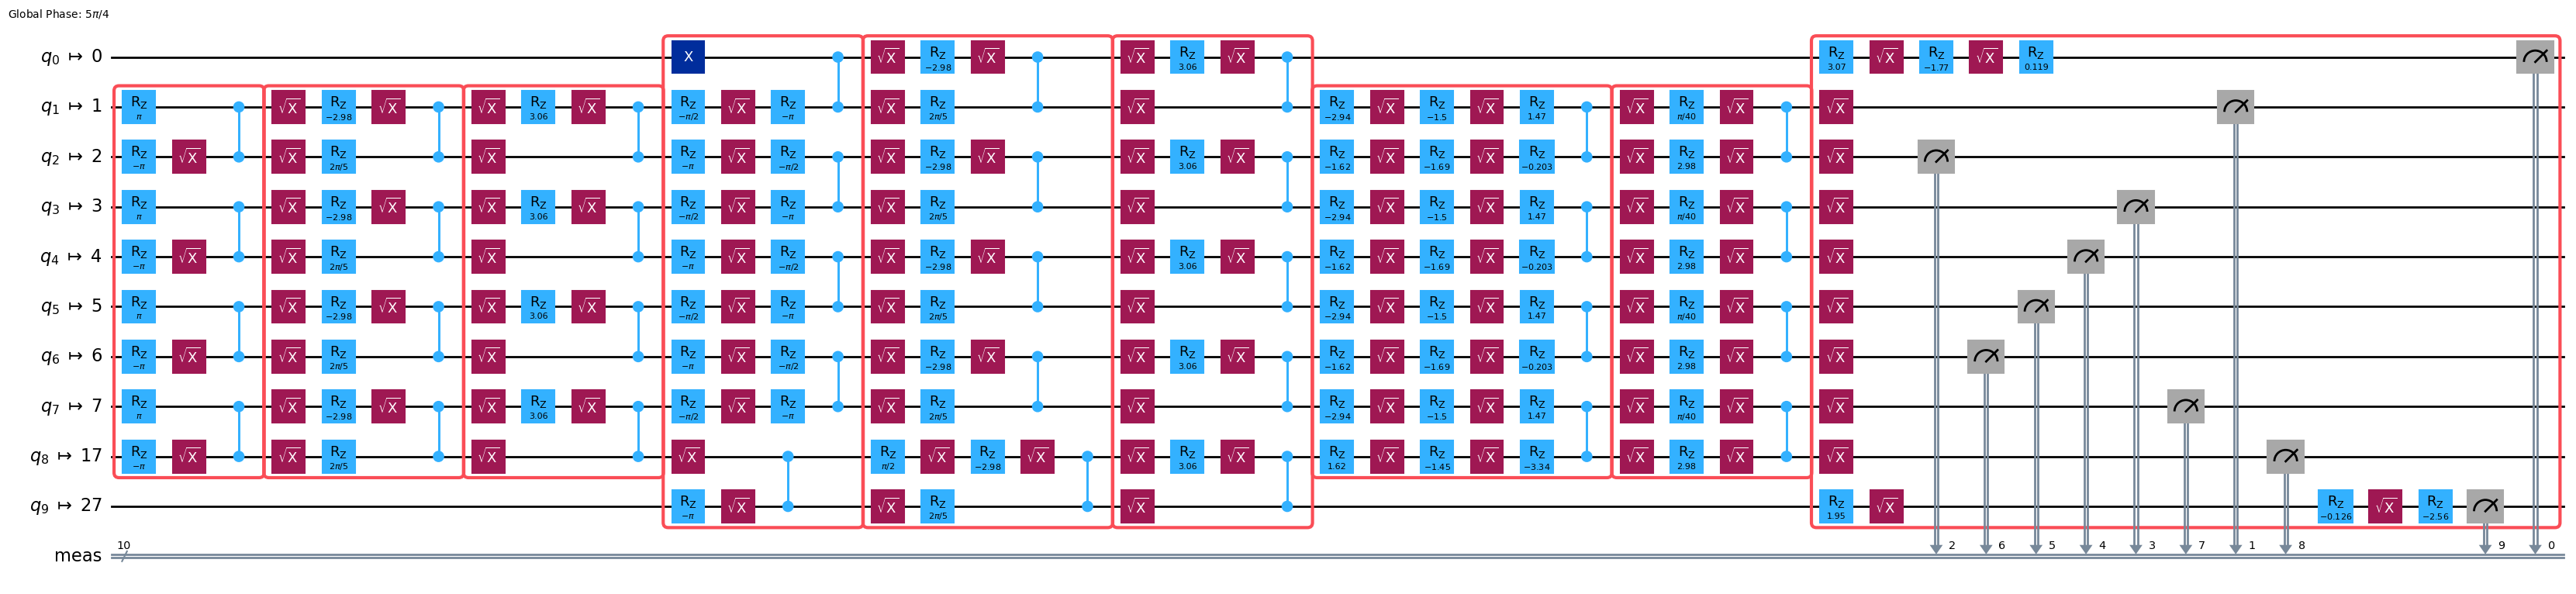

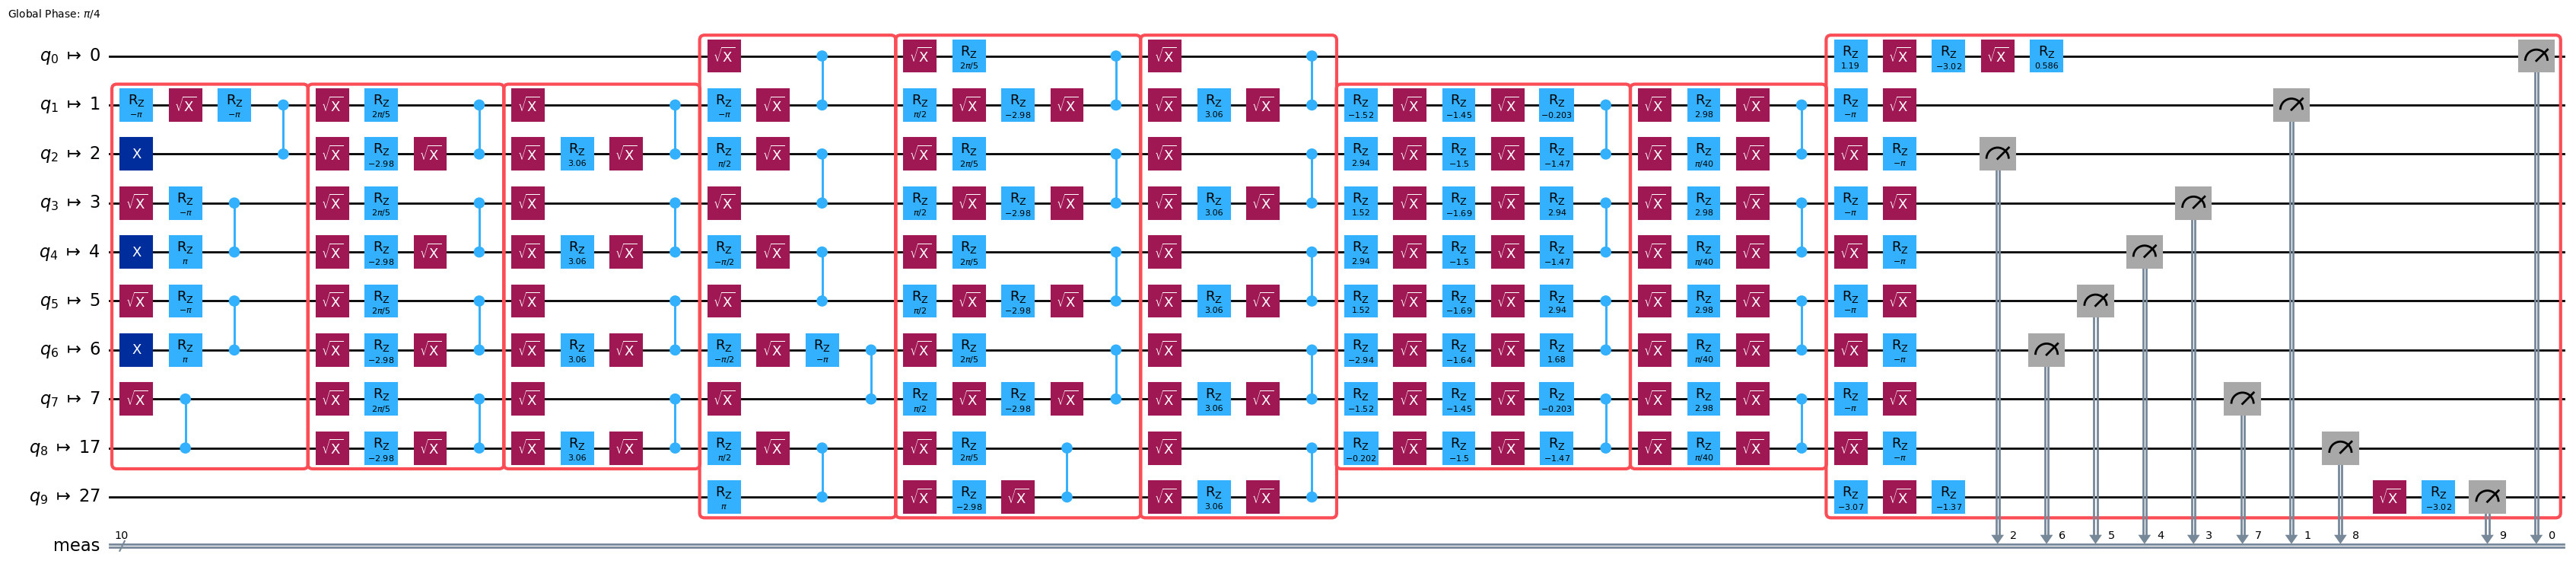

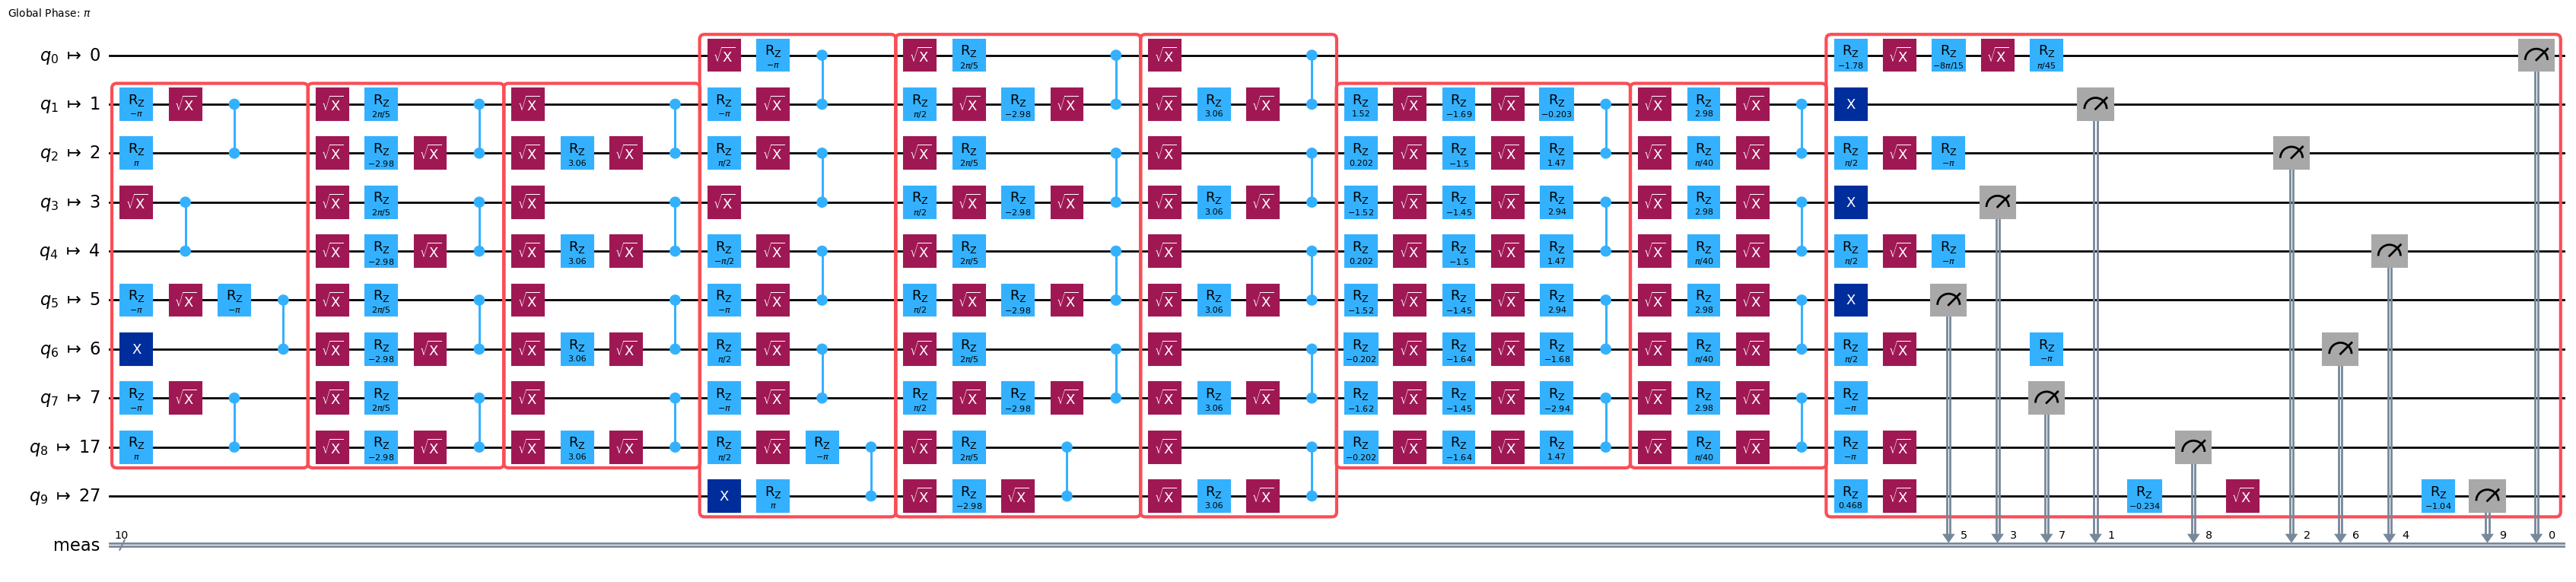

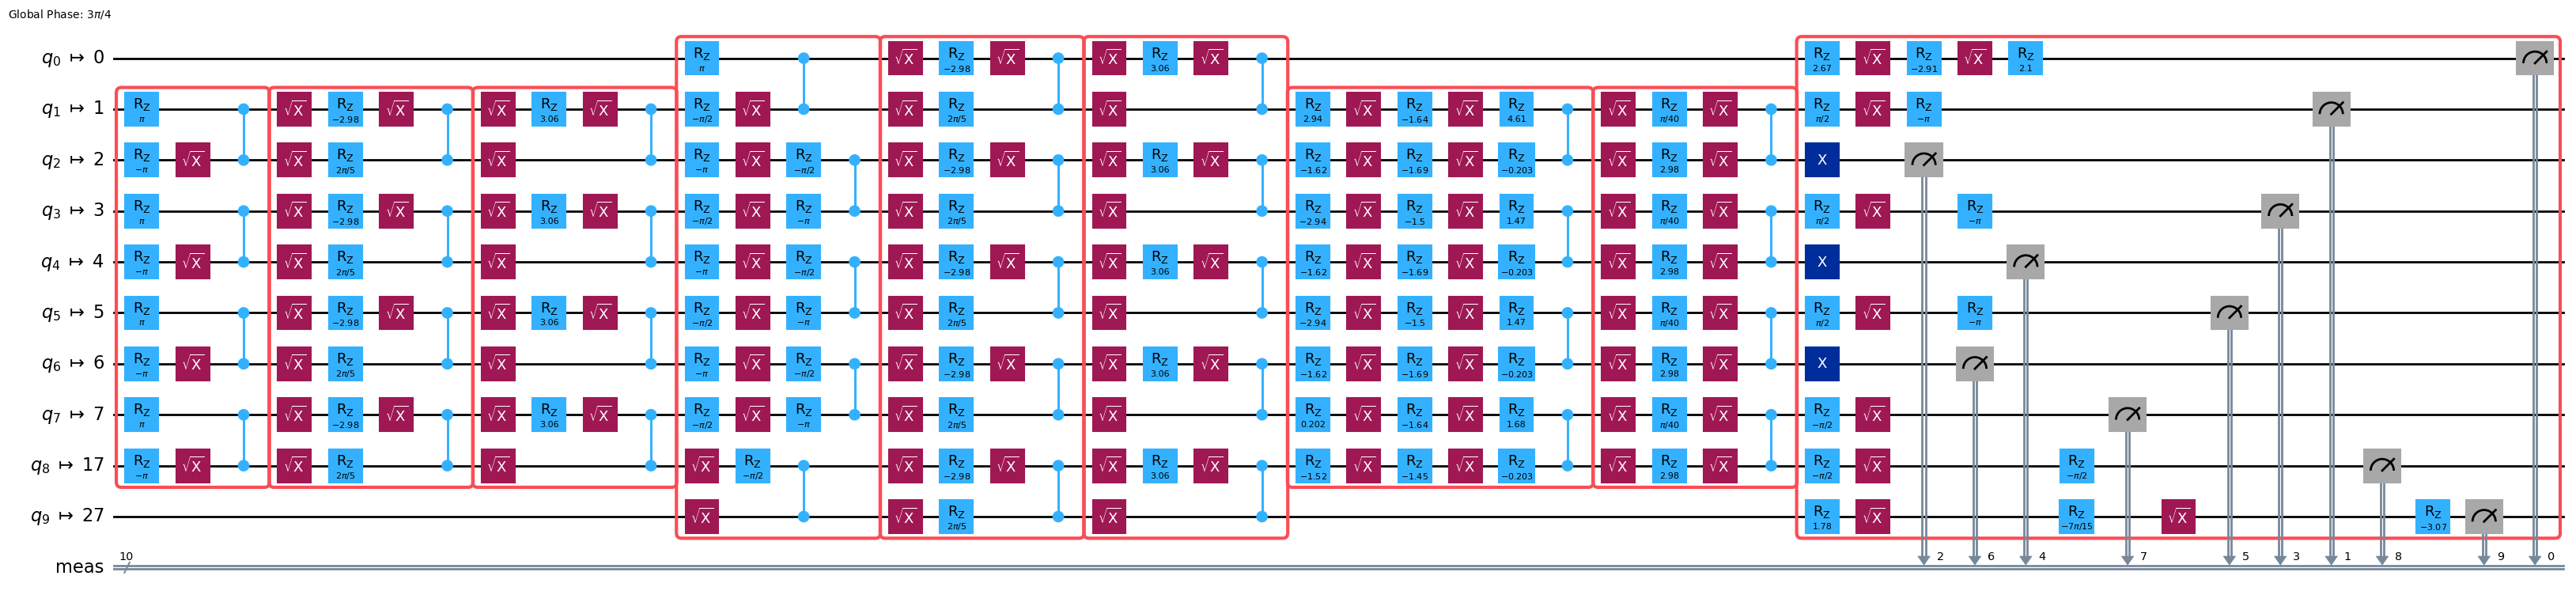

In [95]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42)
pm.post_scheduling = generate_boxing_pass_manager(
    enable_gates=True,
    enable_measures=True,
    twirling_strategy='active'
)

isa_circuits = pm.run(measured_circuits)
for isa_circuit in isa_circuits:
    fig = isa_circuit.draw('mpl', style='iqp', fold=-1, idle_wires=False)
    display(fig)

We have 8 circuits now due to max_qwc_groups=8 (82 terms of the observable are grouped into 8 groups of mutually commuting terms).

In [ ]:
isa_mapped_groups = []

# Map the observables to the physical hardware layouts
for group_idx, isa_qc in enumerate(isa_circuits):
    
    logical_group = commuting_groups[group_idx]
    physical_group = logical_group.apply_layout(isa_qc.layout)
    isa_mapped_groups.append(physical_group)

len(isa_mapped_groups)

8

In [98]:
from qiskit_ibm_runtime import QuantumProgram, Executor

shots_per_randomization = 40
shape = 100 # so essentially 4000 shots

program = QuantumProgram(shots=shots_per_randomization)

In [99]:

post_selection_pm = PassManager(
    [
        AddSpectatorMeasures(backend_f.coupling_map, add_barrier=True),
        AddPostSelectionMeasures(x_pulse_type="rx"),
    ]
)

for isa_circuit in isa_circuits:
    template_circuit, samplex = build(isa_circuit)
    template_circuit_ps = post_selection_pm.run(template_circuit)
    program.append_samplex_item(template_circuit_ps, samplex=samplex, shape=(shape,))

program


QuantumProgram(shots=40, items=[
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x794023f9ba10>, <Samplex @ 0x79402359b110>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x794023f981b0>, <Samplex @ 0x7940235b93b0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29ce0a0>, <Samplex @ 0x79402354e5d0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cf6a0>, <Samplex @ 0x7940235b3890>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cdf40>, <Samplex @ 0x794023571130>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cc310>, <Samplex @ 0x7940235640f0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cd700>, <Samplex @ 0x79402354e3f0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cd020>, <Samplex @ 0x794023455810>, shape=(100,)),
])

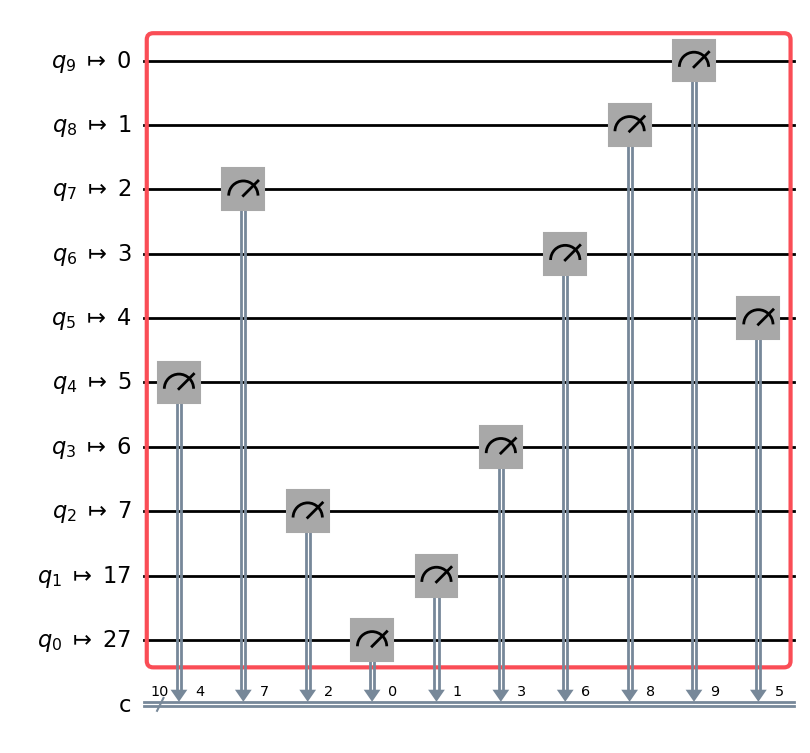

In [100]:
from qiskit import QuantumCircuit

trex_circuit = QuantumCircuit(circuit.num_qubits, circuit.num_qubits)
trex_circuit.measure(range(circuit.num_qubits), range(circuit.num_qubits))

layout = isa_circuits[0].layout.final_index_layout() # I verified that all the circuits have the same physical layout, so we can just use the first one for transpilation
pm_trex = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42, initial_layout=layout)
pm_trex.post_scheduling = generate_boxing_pass_manager(
    enable_gates=False,
    enable_measures=True,
    twirling_strategy='active'
)
trex_circuit = pm_trex.run(trex_circuit)
trex_circuit.draw('mpl', fold=-1, idle_wires=False)

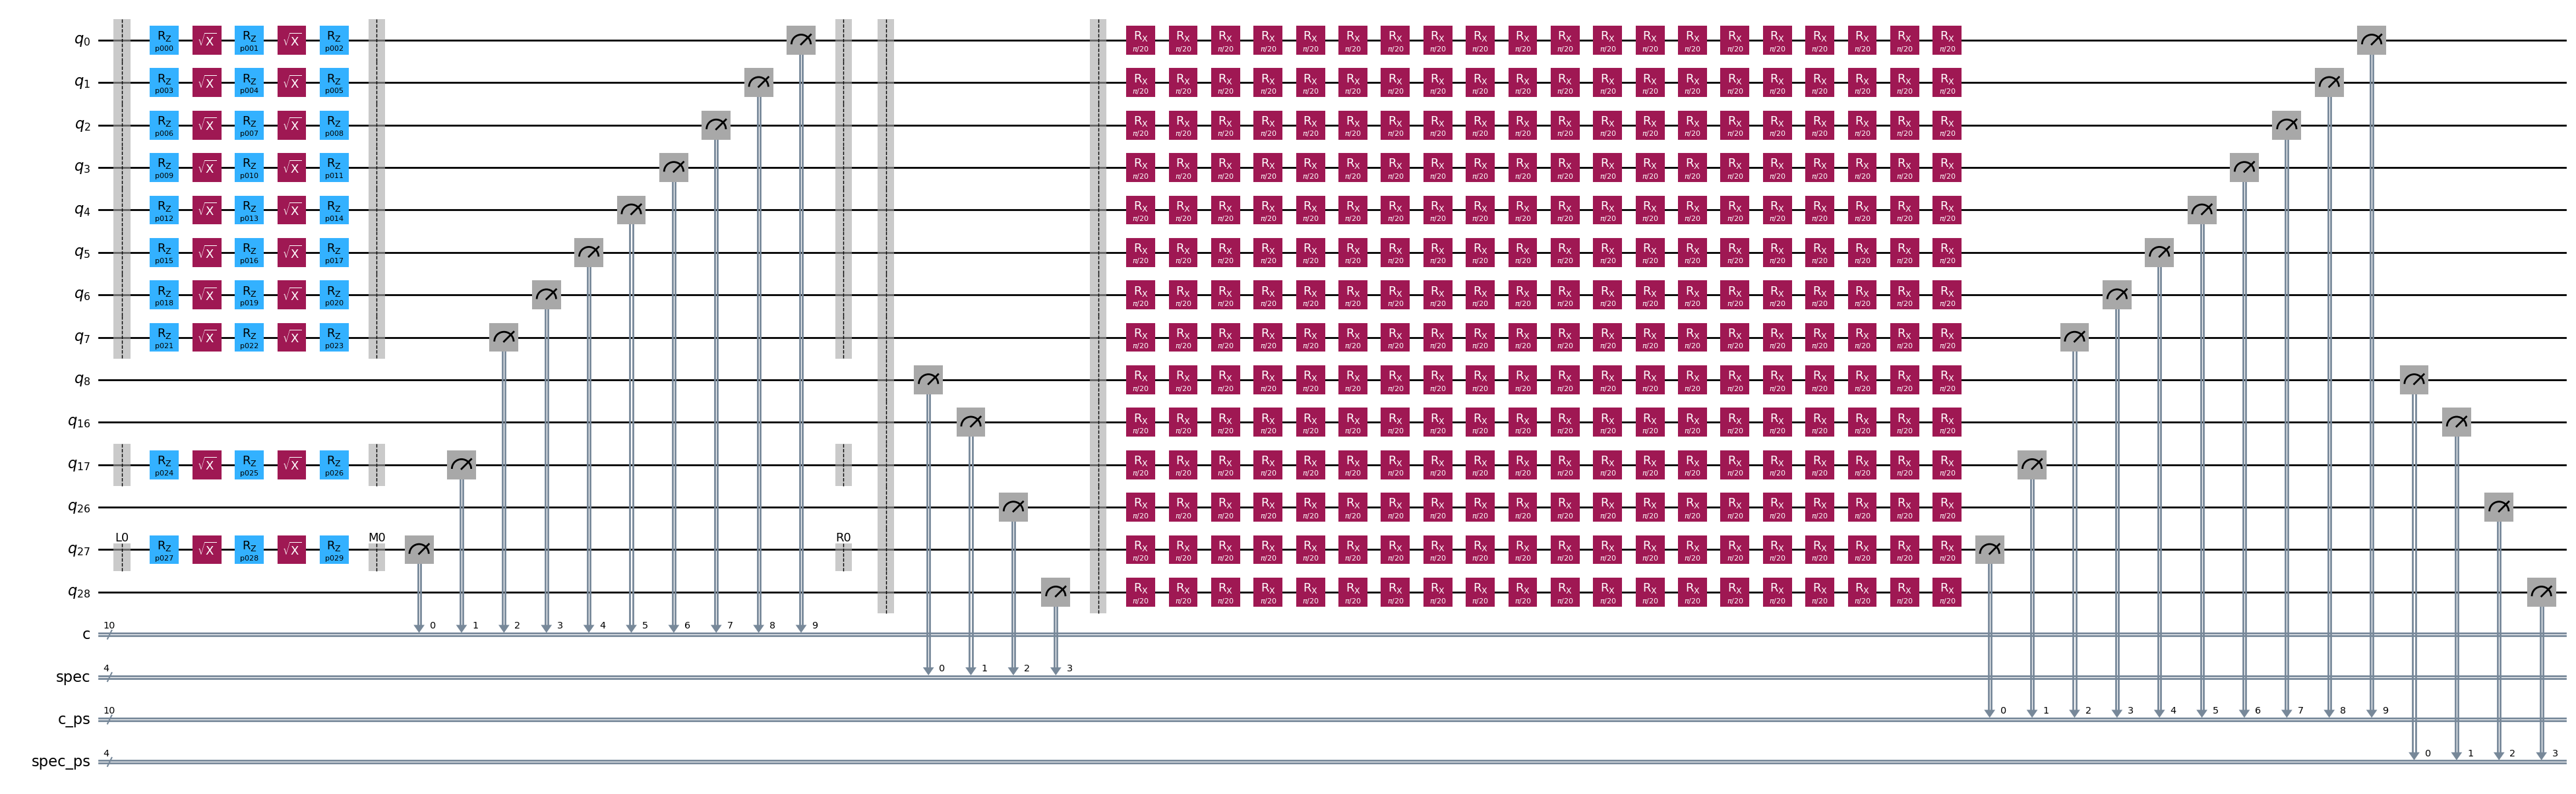

In [101]:
trex_template, trex_samplex = build(trex_circuit)
trex_template_ps = post_selection_pm.run(trex_template)
trex_template_ps.draw('mpl', fold=-1, idle_wires=False)

In [102]:
program.append_samplex_item(trex_template_ps, samplex=trex_samplex, shape=(shape,))
program

QuantumProgram(shots=40, items=[
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x794023f9ba10>, <Samplex @ 0x79402359b110>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x794023f981b0>, <Samplex @ 0x7940235b93b0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29ce0a0>, <Samplex @ 0x79402354e5d0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cf6a0>, <Samplex @ 0x7940235b3890>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cdf40>, <Samplex @ 0x794023571130>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cc310>, <Samplex @ 0x7940235640f0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cd700>, <Samplex @ 0x79402354e3f0>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cd020>, <Samplex @ 0x794023455810>, shape=(100,)),
    QuantumProgramSamplexItem(<QuantumCircuit @ 0x793fc29cd180>, <Samplex @ 0x794023570410>, shape=(100

We have 9 program items because we also have the trex circuit

In [103]:
executor = Executor(backend_f) # make sure to run on backend with fractional gates enabled
executor_job = executor.run(program)
print(f'Job ID: {executor_job.job_id()}')

qiskit_runtime_service.backends:WARNING:2026-03-26 10:03:10,900: Using instance: open-instance, plan: open


Job ID: d72g8okscmvs73abvm80


In [ ]:

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

past_job = service.job('d72g8okscmvs73abvm80')

print(past_job.status())




qiskit_runtime_service.__init__:WARNING:2026-03-26 10:03:50,606: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


DONE


In [106]:
all_results = past_job.result()

executor_results = all_results[:-1]
trex_result = all_results[-1]
executor_results[0].keys()

dict_keys(['meas', 'spec', 'meas_ps', 'spec_ps', 'measurement_flips.meas'])

In [108]:
import numpy as np
np.shape(executor_results[0]['meas'])

(100, 40, 10)

In [109]:
import numpy as np
np.shape(executor_results[0]['spec'])

(100, 40, 4)

This shows that we 40 trials (shots) for each of the 100 variations of the template circuit, resulting in a total of 4000 measurements. 14 qubits were used in total, 10 for the circuit, 4 as spectator qubits.

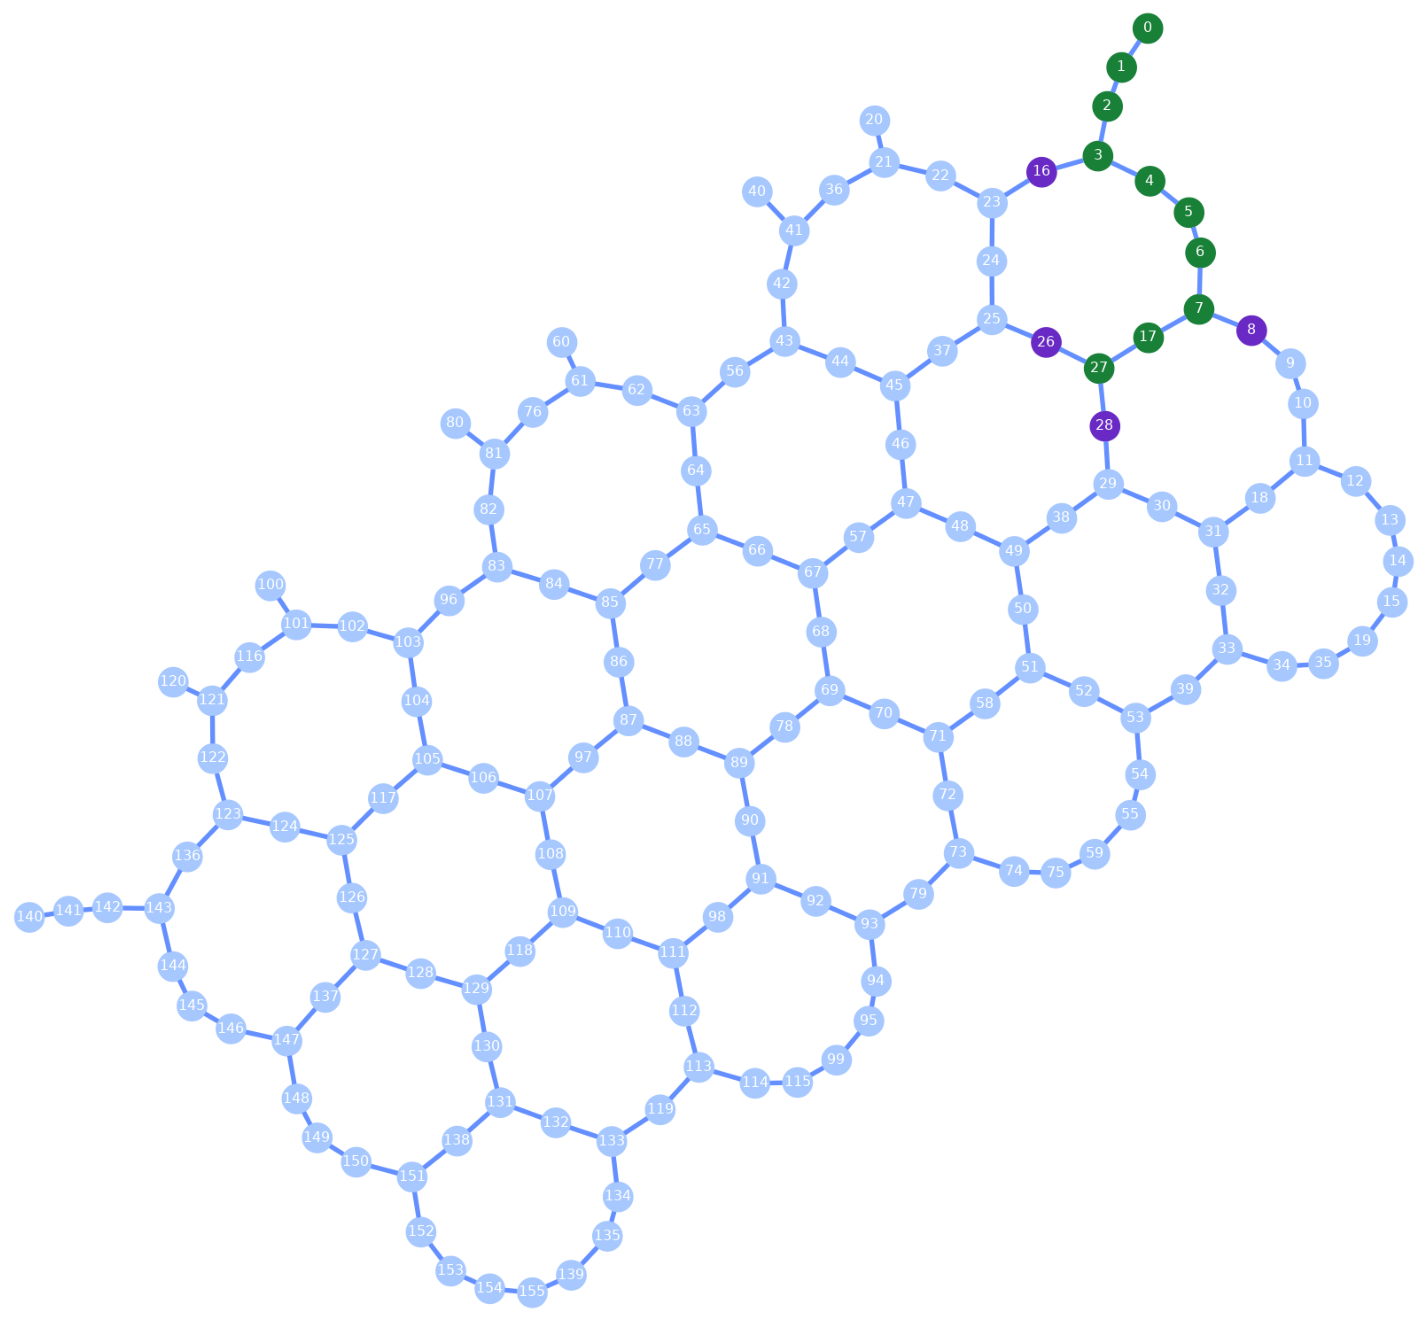

In [111]:
from qiskit.visualization import plot_gate_map
qubit_colors = ['#a6c8ff' for _ in range(backend.num_qubits)]

spectators = [8, 16, 28, 26]
for spectator in spectators:
    qubit_colors[spectator] = '#6929c4'

for qubit in isa_circuit.layout.final_index_layout():
    qubit_colors[qubit] = '#198038'

plot_gate_map(backend, qubit_color=qubit_colors)

Hence it is clear why 14 qubits were used, 10 qubits were utilized for the Ising model and 4 qubits were used as spectators. The spectator qubits are used to capture the noise characteristics of the quantum device, which can then be used to improve the accuracy of the results obtained from the Ising model.

In [118]:
from qiskit_addon_utils.noise_management.post_selection import PostSelector

masks = []

for group_idx, executor_result in enumerate(executor_results):
    template_circuit = program.items[group_idx].circuit

    post_selector = PostSelector.from_circuit(
            circuit=template_circuit, coupling_map=backend.coupling_map
        )
    mask_node = post_selector.compute_mask(executor_result, strategy="node")
    mask_edge = post_selector.compute_mask(executor_result, strategy="edge")
    mask = mask_node & mask_edge
    masks.append(mask)
masks[0][0]

array([False, False,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False, False, False, False, False, False, False,
       False,  True,  True, False,  True, False, False, False, False,
       False,  True, False,  True, False, False, False, False,  True,
       False,  True,  True, False])

In [116]:
results_unflipped = []
for executor_result in executor_results:
    result_unflipped = executor_result["meas"] ^ executor_result["measurement_flips.meas"]
    results_unflipped.append(result_unflipped)

In [120]:
all_counts_raw = []

for result_unflipped in results_unflipped:
    counts = {}
    
    num_randomizations = len(result_unflipped)
    shots_per_randomization = len(result_unflipped[0])
    total_shots = num_randomizations * shots_per_randomization
    
    for val in result_unflipped:
        for result in val:
            count = ''
            for b in result:
                count += str(int(b))
            
            if count in counts:
                counts[count] += 1
            else:
                counts[count] = 1

    for key, val in counts.items():
        counts[key] = float(val / total_shots)
        
    all_counts_raw.append(counts)

print(all_counts_raw[0])

{'0010000100': 0.01175, '0000000100': 0.00475, '1010000001': 0.0085, '0011000001': 0.017, '1011100100': 0.0005, '1001000101': 0.00725, '0010100001': 0.00025, '0110001101': 0.00075, '0001111100': 0.001, '1001000000': 0.01, '0011001000': 0.0175, '0011011000': 0.00575, '0001000000': 0.01825, '0101001001': 0.00025, '1000010000': 0.0025, '1010111101': 0.001, '1010001000': 0.009, '0011000100': 0.0195, '0011111001': 0.00075, '0001001101': 0.01025, '0010010101': 0.003, '0001000100': 0.012, '1001100101': 0.001, '1010101101': 0.00075, '0011000000': 0.02325, '0001000101': 0.0105, '0010100101': 0.0005, '0001001001': 0.00975, '0000000101': 0.00625, '0011001001': 0.016, '0011011101': 0.00225, '1011001101': 0.00975, '1010110000': 0.00075, '0010001000': 0.012, '1000000110': 0.001, '1001001000': 0.0085, '0000011000': 0.00275, '0010000000': 0.01375, '0111001000': 0.00175, '1001010100': 0.003, '0011101001': 0.001, '0000010000': 0.00325, '1001011000': 0.00175, '0001001000': 0.009, '0011010100': 0.0045, '0

In [121]:
all_counts_ps = []

for result_unflipped, mask in zip(results_unflipped, masks):
    counts_ps = {}
    for m in mask:
        count_retained += sum(m)
    
    for idx, val in enumerate(result_unflipped):
        for twirl_idx, result in enumerate(val):
            if mask[idx][twirl_idx]:
                count=''
                for b in result:
                    count += str(int(b))
                
                if count in counts_ps:
                    counts_ps[count] += 1
                else:
                    counts_ps[count] = 1
    for key, val in counts_ps.items():
        counts_ps[key] = val / (count_retained)
    all_counts_ps.append(counts_ps)
print(all_counts_ps[0])

{'1010000001': np.float64(0.0006448284756254836), '0011000001': np.float64(0.001612071189063709), '1011100100': np.float64(6.448284756254837e-05), '1001000101': np.float64(0.000709311323188032), '0010100001': np.float64(6.448284756254837e-05), '0110001101': np.float64(6.448284756254837e-05), '0001111100': np.float64(0.00012896569512509673), '0011001000': np.float64(0.001612071189063709), '0001001101': np.float64(0.0009672427134382255), '0010010101': np.float64(0.00038689708537529015), '1001100101': np.float64(0.00019344854268764507), '0000000101': np.float64(0.00045137993293783854), '0011001001': np.float64(0.0017410368841888058), '0001000100': np.float64(0.0012251741036884188), '0010001000': np.float64(0.0009672427134382255), '0111001000': np.float64(0.00025793139025019347), '0011101001': np.float64(0.00019344854268764507), '1001011000': np.float64(0.00012896569512509673), '0000001000': np.float64(0.0007737941707505803), '1010010000': np.float64(0.00038689708537529015), '0010000000': 

The histogram turns out to be very messy due to the long bitstrings, hence I have avoided displaying it.

No changes in TREX part of processing.

In [123]:
trex_result.keys()

dict_keys(['c', 'spec', 'c_ps', 'spec_ps', 'measurement_flips.c'])

In [124]:
post_selector_trex = PostSelector.from_circuit(
        circuit=trex_template_ps, coupling_map=backend.coupling_map
    )

mask_node_trex = post_selector_trex.compute_mask(trex_result, strategy="node")
mask_edge_trex = post_selector_trex.compute_mask(trex_result, strategy="edge")

In [125]:
mask_trex = mask_node_trex & mask_edge_trex
print(f'The combined mask for first twirl instance for trex: {mask_trex[0]}')

The combined mask for first twirl instance for trex: [ True False  True False  True  True False  True  True False False  True
  True  True  True  True False  True  True  True False  True False  True
  True False False False  True  True False  True False False False False
  True False  True  True]


In [126]:
count_retained_trex = 0

for m in mask_trex:
    count_retained_trex += sum(m)

print(f'Percentage of the shots retained is after post selection for trex {100 * count_retained_trex / (shots_per_randomization*shape)}')

Percentage of the shots retained is after post selection for trex 35.95


In [127]:
trex_corrected = trex_result["c"] ^ trex_result["measurement_flips.c"]
counts_trex = {}

for idx, val in enumerate(trex_corrected):
    for twirl_idx, result in enumerate(val):
        if mask_trex[idx][twirl_idx]:
            count = ''
            for b in result:
                count += str(int(b))
            
            if count in counts_trex:
                counts_trex[count] += 1
            else:
                counts_trex[count] = 1

for key, val in counts_trex.items():
    counts_trex[key] = float(val/count_retained_trex)

counts_trex

{'0000000000': 0.8344923504867872,
 '0010000000': 0.005563282336578581,
 '1000000000': 0.009735744089012517,
 '0000000100': 0.002086230876216968,
 '0100000000': 0.006258692628650904,
 '0000010000': 0.09805285118219749,
 '1000010000': 0.0027816411682892906,
 '0001000000': 0.009040333796940195,
 '0000001000': 0.006258692628650904,
 '0000100000': 0.004172461752433936,
 '0000000010': 0.012517385257301807,
 '0000010010': 0.002086230876216968,
 '0000010100': 0.0006954102920723226,
 '0100010000': 0.0006954102920723226,
 '0000000001': 0.0027816411682892906,
 '0010010000': 0.0006954102920723226,
 '0001000010': 0.0006954102920723226,
 '0000011000': 0.0006954102920723226,
 '0001000100': 0.0006954102920723226}

In [129]:
from qiskit.result import sampled_expectation_value
from qiskit.quantum_info import SparsePauliOp
observable = SparsePauliOp(['I'*i + 'Z' + 'I'*(circuit.num_qubits - i - 1) for i in range(circuit.num_qubits)],
                            coeffs=[1/circuit.num_qubits]*circuit.num_qubits
                          )
trex_expval = sampled_expectation_value(counts_trex, observable)
trex_expval

0.9650904033379694

In [ ]:
from qiskit.quantum_info import SparsePauliOp

raw_expval_sum = 0
ps_expval_sum = 0

# Loop through the 8 observable groups and their corresponding distributions
for idx, obs_group in enumerate(commuting_groups):
    
    # We need to replace the X and Y in the observable with Z for the classical post-processing since we rotated the measurement basis to Z-basis
    z_paulis = [str(pauli).replace('X', 'Z').replace('Y', 'Z') for pauli in obs_group.paulis]
    diagonal_obs = SparsePauliOp(z_paulis, obs_group.coeffs)
    
    raw_val = sampled_expectation_value(all_counts_raw[idx], diagonal_obs)
    raw_expval_sum += raw_val
    
    ps_val = sampled_expectation_value(all_counts_ps[idx], diagonal_obs)
    ps_expval_sum += ps_val


final_mitigated_expval = ps_expval_sum / trex_expval

print(f"Raw Expectation Value: {raw_expval_sum.real:.5f}")
print(f"Post-Selected Expectation Value: {ps_expval_sum.real:.5f}")
print(f"Fully Mitigated (TREX) Expectation Value: {final_mitigated_expval.real:.5f}")

Raw Expectation Value: 0.83934
Post-Selected Expectation Value: 0.85626
Fully Mitigated (TREX) Expectation Value: 0.88723


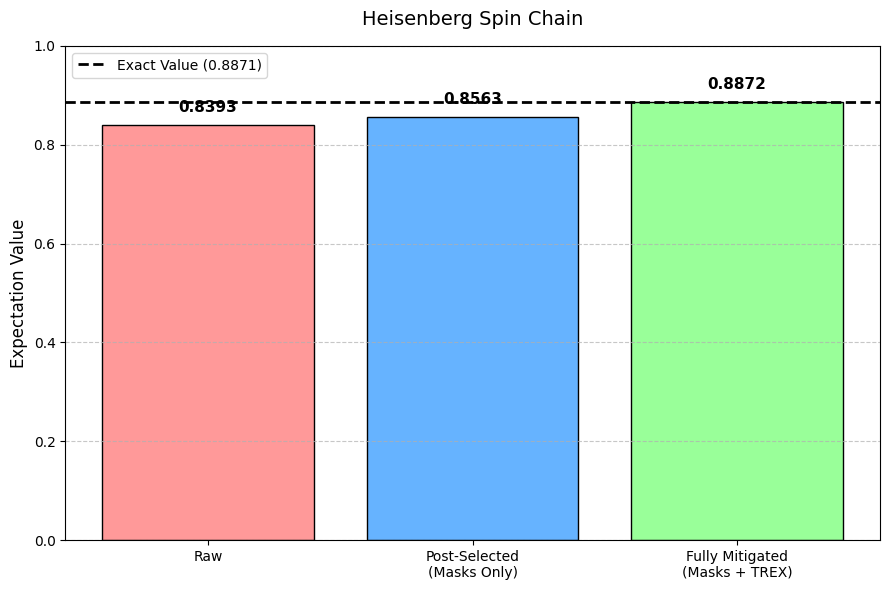

In [ ]:
exact_value = 0.8871244838989416 # Used the same value as in the OBP tutorial on Qiskit Tutorials


labels = ['Raw', 'Post-Selected\n(Masks Only)', 'Fully Mitigated\n(Masks + TREX)']
values = [raw_expval_sum, ps_expval_sum, final_mitigated_expval]


fig, ax = plt.subplots(figsize=(9, 6))


bars = ax.bar(labels, values, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')


ax.axhline(y=exact_value, color='black', linestyle='--', linewidth=2, label=f'Exact Value ({exact_value:.4f})')


ax.set_ylabel('Expectation Value', fontsize=12)
ax.set_title('Heisenberg Spin Chain', fontsize=14, pad=15)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()